In [7]:
import numpy as np
from numpy.polynomial.polynomial import polyvander
from matplotlib.pyplot import *

x = [2.5]
y = [7]
vdm = polyvander(x,(len(x)-1))
Y = np.linalg.solve(vdm, y)
print(Y)

[7.]


In [9]:
I = np.array([[2.0,4.1], [2.5,3.8]])
print(I)

[[2.  4.1]
 [2.5 3.8]]


[224.92243799, 66.17289251] [69.93805979 64.13233494]


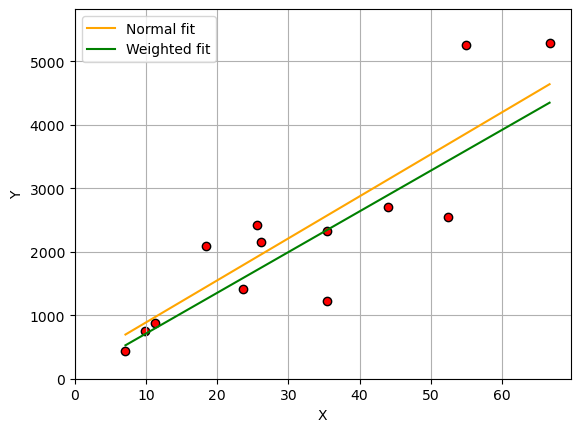

In [6]:
# Some Hubble data with 1 sigma errors on both distance and velocity
import numpy as np
data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]


data = np.asarray(data)
x = data[0::4]; y = data[1::4]
sigx= data[2::4]; sigy= data[3::4]
# The result of a fit without weights:
beta_lsq = [224.92243799,  66.17289251]
import numpy as np
from scipy.optimize import leastsq

# The model, usually a function of x
def model(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x

# A residuals function
def residuals(beta, x, y, sigy):
    return (y - model(beta,x))/sigy

beta_start = [0, 70.0]          # Initial estimates for beta0 and beta1
data = (x, y, sigy)             # You need to pack your data in a tuple
result = leastsq(residuals, beta_start, args=data, full_output=1)
(beta, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results

# Convert unscaled standard errors to scaled standard errors
# No need to understand this code
if not pcov is None:
    # Note that 'fvec' are residuals, not function
    # values according to the documentation
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()
    perror = np.sqrt(pcov.diagonal())        # Trusted as the weights are realistic
    dof = len(fvec) - len(beta)              # Number of degrees of freedom
    # Uncertainties for unweighted data
    sderr = perror * np.sqrt(chi2/dof)

beta_lsqwei = beta

from matplotlib.pyplot import figure, show

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x, y, marker='o', ec='k', color='r')
xmin = x.min(); xmax = x.max()
ymin = model(beta_lsq,xmin); ymax = model(beta_lsq,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Normal fit", color='orange')
ymin = model(beta_lsqwei,xmin); ymax = model(beta_lsqwei,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Weighted fit", color='green')
print(beta_lsq, beta_lsqwei)
frame.set_xlabel('X')
frame.set_ylabel('Y')
frame.set_xlim(0, None)
frame.set_ylim(0, 1.1*y.max())
frame.grid()
frame.legend()
show()

In [8]:
class Galaxy:
    """Class for redshift calculation of galaxies"""

    caH_0 = 3968.5  # Calcium H line in rest frame

    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
    def redshift(self):
        z = (self.caH - self.caH_0)/self.caH_0
        return z
    def __str__(self):
        s = f"Galaxy name: {self.name}  Redshift: {self.redshift():.5f}"
        return s

# Initialize some objects
gal1 = Galaxy("NGC1357")
gal2 = Galaxy("NGC1832", 3994.7)

print(gal2.redshift())

0.006601990676578007


In [11]:
import numpy as np
from scipy import interpolate as ip
from matplotlib.pyplot import figure, show
from numpy.polynomial.polynomial import polyvander

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

vdm = polyvander(x,(len(x)-1))
pi = np.linalg.solve(vdm, y)
print(pi)

[ 2.18582332e+02 -5.51003146e+02  5.65812237e+02 -3.13633556e+02
  1.04544074e+02 -2.19331360e+01  2.91867715e+00 -2.39059756e-01
  1.09925609e-02 -2.17117476e-04]


In [12]:
from matplotlib.pyplot import subplots, show
from scipy.optimize import curve_fit

data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

data = np.asarray(data)
d = data[0::4]; v = data[1::4]
err_d = data[2::4]; err_v= data[3::4]
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
def model(d, beta0, beta1):
    """The model with parameters a and b. Note that for the Hubble relation we fix a to 0.0"""
    return beta0 + beta1*d

# Do the fitting
beta, pcov = curve_fit(model, d, v)

# Calculate end points for the best straight line
X = np.array([d.min(),d.max()])
Y = model(X, beta[0], beta[1])

dbeta = np.sqrt(np.diag(pcov))   # Standard error
print("Best fit model parameters")
s = f"Intercept beta0 = {beta[0]:.2f} \u00B1 {dbeta[0]:.2f}"
print(s)
s = f"Slope     beta1 = {beta[1]:.2f} \u00B1 {dbeta[1]:.2f}"
print(s)

Best fit model parameters
Intercept beta0 = 9.19 ± 433.41
Slope     beta1 = 71.38 ± 11.92


In [ ]:
import numpy as np
from matplotlib.pyplot import figure, show
from scipy.optimize import leastsq

import numpy as np
data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]


data = np.asarray(data)
d = data[0::4]; v = data[1::4]
err_d = data[2::4]; err_v= data[3::4]

# The result of a fit without weights:
beta_lsq = [224.92243799,  66.17289251]

# The model, usually a function of x
def model(beta, d):
    beta0, beta1 = beta
    return beta0 + beta1*d

# A residuals function
def residuals(beta, d, v, err_v):
    return (v - model(beta,d))/err_v

beta_start = [0, 70.0]          # Initial estimates for beta0 and beta1
data = (d, v, err_v)             # You need to pack your data in a tuple
result = leastsq(residuals, beta_start, args=data, full_output=1)
(beta, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results

# Convert unscaled standard errors to scaled standard errors
if not pcov is None:
    # Note that 'fvec' are residuals, not function
    # values according to the documentation
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()
    perror = np.sqrt(pcov.diagonal())        # Trusted as the weights are realistic
    dof = len(fvec) - len(beta)              # Number of degrees of freedom
    # Uncertainties for unweighted data
    sderr = perror * np.sqrt(chi2/dof)

print( "Params: ", beta)